<class 'pandas.core.frame.DataFrame'>
Index: 5415 entries, 0 to 6946
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   COSMIC_ID                                5415 non-null   int64  
 1   CELL_LINE_NAME                           5415 non-null   object 
 2   TCGA_DESC                                5415 non-null   object 
 3   DRUG_ID                                  5415 non-null   int64  
 4   DRUG_NAME                                5415 non-null   object 
 5   LN_IC50                                  5415 non-null   float64
 6   AUC                                      5415 non-null   float64
 7   Z_SCORE                                  5415 non-null   float64
 8   GDSC Tissue descriptor 1                 5415 non-null   object 
 9   GDSC Tissue descriptor 2                 5415 non-null   object 
 10  Cancer Type (matching TCGA label)        5415 non-nul

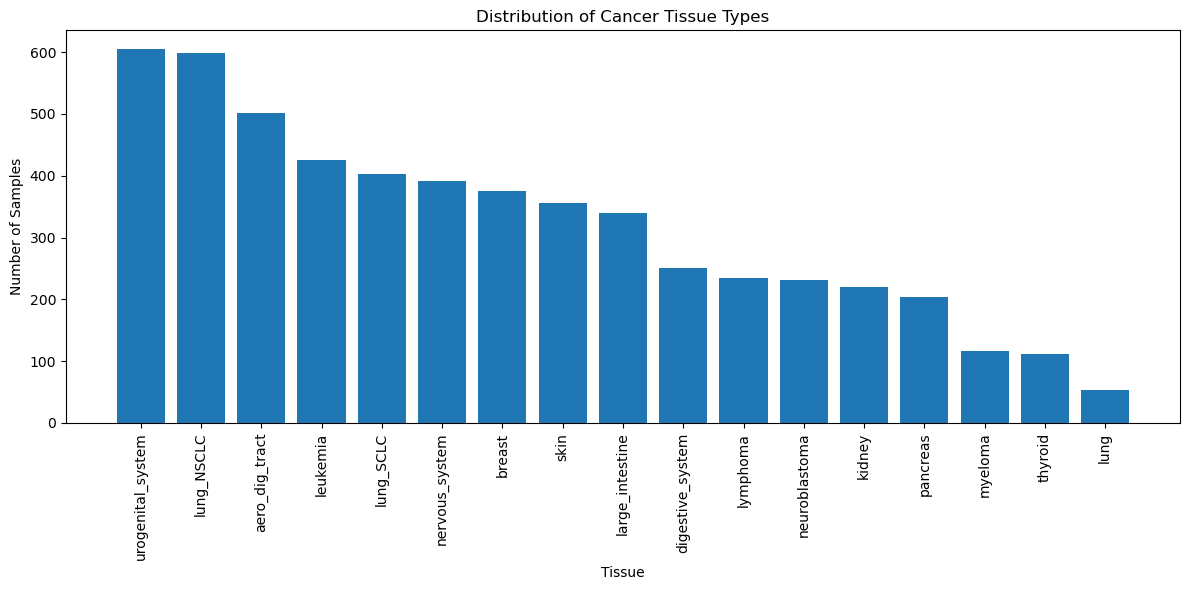

In [56]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
df=pd.read_csv("GDSC_DATASET.csv")
#print(df)
df.dropna(inplace = True)
df.info()
prevalent_cancer_type=df['GDSC Tissue descriptor 1'].describe()
cancer_type=prevalent_cancer_type['top']
cancer_count=prevalent_cancer_type['freq']
print(f"The most prevalent cancer type is in {cancer_type} in with count {cancer_count}")


if cancer_type== "urogenital_system":
    filt_df=df[df['GDSC Tissue descriptor 1']=='urogenital_system']
    prevalent_cancer_sub_type=filt_df['GDSC Tissue descriptor 2'].describe()
    cancer_sub_type=prevalent_cancer_sub_type['top']
    cancer_sub_count=prevalent_cancer_sub_type['freq']
    print(f"The most prevalent cancer type is in {cancer_sub_type} in with count {cancer_sub_count}")

    
df.replace('MSS/MSI-L','MSI-L',inplace=True)
msi_df=df[df['Microsatellite instability Status (MSI)']=='MSI-H']
instable_cancer=msi_df['GDSC Tissue descriptor 1'].describe()
instable_cancer_type=instable_cancer['top']
print(f"The {instable_cancer_type} has the most instable genes in the given dataset")


cn_df=df[df["CNA"]=='Y']
altered_gene_tumor=df['GDSC Tissue descriptor 1'].describe()
altered_gene_tumor_type=altered_gene_tumor['top']
altered_gene_tumor_count=altered_gene_tumor['freq']
print(f"Altered copy of genes were observed the most in{altered_gene_tumor_type},with a count of {altered_gene_tumor_count} cases")


m = df.groupby(['GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2']).size().reset_index(name="tot_cases")


d = m.groupby('GDSC Tissue descriptor 1')['tot_cases'].idxmax()


final_result = m.loc[d]


print(final_result)


drug_info=df['DRUG_NAME'].describe()
most_used_drug=drug_info['top']
drug_freq=drug_info['freq']
print(f"The most used drug is {most_used_drug} with  a count of {drug_freq}")
import matplotlib.pyplot as plt

tissue_counts = df["GDSC Tissue descriptor 1"].value_counts()

plt.figure(figsize=(12,6))
plt.bar(tissue_counts.index, tissue_counts.values)
plt.xticks(rotation=90)
plt.title("Distribution of Cancer Tissue Types")
plt.xlabel("Tissue")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr,skew
from sklearn.linear_model import LinearRegression
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
df=pd.read_csv("GDSC_DATASET.csv")
#print(df)
df.dropna(inplace = True)
df.info()

drug_analysis=df['DRUG_NAME'].describe()
print(f"Number of unique drugs are {drug_analysis['unique']}")
tumor_type_analysis=df['GDSC Tissue descriptor 1'].describe()
print(f"Number of unique tumor types are {tumor_type_analysis['unique']}")
target_analysis=df['TARGET'].describe()
print(f"Number of unique target types are {target_analysis['unique']}")
cell_line_analysis=df['CELL_LINE_NAME'].describe()
print(f"Number of unique cell lines are {cell_line_analysis['unique']}")


df['LN_IC50'].median()
df['LN_IC50'].mode()
ln_skewness=skew(df['LN_IC50'])#=-0.21 indicating fairly skewed
print(f"{ln_skewness:.2f}")
auc_skewness=skew(df['AUC'])#-> -1.44 negatively skewed , the curve is more towards left 
print(f"{auc_skewness:.2f}")
zscore_skewness=skew(df['Z_SCORE'])#=> -0.02 fairly skewed
print(f"{zscore_skewness:.2f}")
unique_drugs = df.loc[df['LN_IC50'] == df['LN_IC50'].min(), 'DRUG_NAME'].unique()
print(unique_drugs)

plt.figure(figsize=(8,5))
plt.hist(df["LN_IC50"], bins=40)
plt.title("Distribution of LN_IC50")
plt.xlabel("LN_IC50")
plt.ylabel("Frequency")
plt.show()
model=LinearRegression()
x=df[['LN_IC50']]
y=df['AUC']
model.fit(x,y)
print(f"Intercept is {model.intercept_:.2f}")
print(f"Coefficient is {model.coef_[0]:.2f}")
print(f"Rsquare is {model.score(x,y):.2f}")

x=df[['LN_IC50']]
y=df['Z_SCORE']
model.fit(x,y)
print(f"Intercept is {model.intercept_:.2f}")
print(f"Coefficient is {model.coef_[0]:.2f}")
print(f"Rsquare is {model.score(x,y):.2f}")
x=df[['AUC']]
y=df['Z_SCORE']
model.fit(x,y)
print(f"Intercept is {model.intercept_:.2f}")
print(f"Coefficient is {model.coef_[0]:.2f}")
print(f"Rsquare is {model.score(x,y):.2f}")
x=df['LN_IC50'].median()
print(x)


resistant_tumor=df.loc[df['LN_IC50']>x,'GDSC Tissue descriptor 1'].unique()
print(f"Resistant_tumors are :{resistant_tumor}")

sensitive_pathways=df.loc[df['LN_IC50']<x,'TARGET_PATHWAY'].unique()
print(f"Sensitive pathways are: {sensitive_pathways}")



    GDSC Tissue descriptor 1     DRUG_NAME  total_drugs
0             aero_dig_tract  Camptothecin           71
12                    breast     Docetaxel           50
18          digestive_system  Camptothecin           33
27                    kidney  Camptothecin           33
36           large_intestine  Camptothecin           45
45                  leukemia  Camptothecin           59
54                      lung  Camptothecin            7
63                lung_NSCLC  Camptothecin           83
72                 lung_SCLC  Camptothecin           58
81                  lymphoma  Camptothecin           36
90                   myeloma  Camptothecin           16
99            nervous_system  Camptothecin           54
108            neuroblastoma  Camptothecin           32
117                 pancreas  Camptothecin           27
126                     skin  Camptothecin           50
135                  thyroid  Camptothecin           15
144        urogenital_system  Camptothecin      

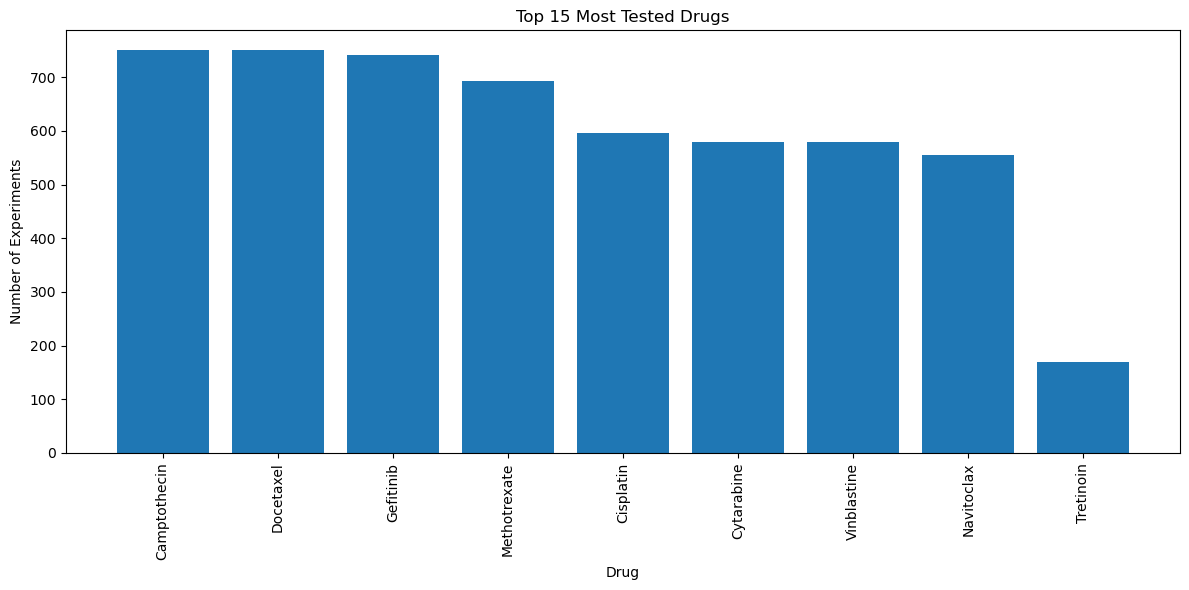

In [57]:
# Disease to Drug comparison

disease_to_drug_count=df.groupby(['GDSC Tissue descriptor 1','DRUG_NAME']).size().reset_index(name='total_drugs')
max_drugs=disease_to_drug_count.groupby('GDSC Tissue descriptor 1')['total_drugs'].idxmax()
drug_for_disease=disease_to_drug_count.loc[max_drugs]
print(drug_for_disease)
top_drugs = df["DRUG_NAME"].value_counts().head(15)

plt.figure(figsize=(12,6))
plt.bar(top_drugs.index, top_drugs.values)
plt.xticks(rotation=90)
plt.title("Top 15 Most Tested Drugs")
plt.xlabel("Drug")
plt.ylabel("Number of Experiments")
plt.tight_layout()
plt.show()

In [ ]:
# Drug_potency (LN_IC50) prediction using cancer cell properties and target mechanism

Training data set performance score is :0.7611483218968457
Testing data set performance score is :0.7493025091612584
Tissue
lung                 2.030514
pancreas             1.612140
thyroid              1.357777
skin                 0.979378
lung_NSCLC           0.776928
nervous_system       0.717677
urogenital_system    0.592546
kidney               0.587349
digestive_system     0.574811
breast               0.545830
lung_SCLC            0.351162
large_intestine      0.181697
aero_dig_tract       0.053987
soft_tissue          0.020642
bone                -0.568246
neuroblastoma       -0.974602
lymphoma            -0.986123
leukemia            -2.021559
myeloma             -2.480683
Name: Predicted Drug Potency, dtype: float64


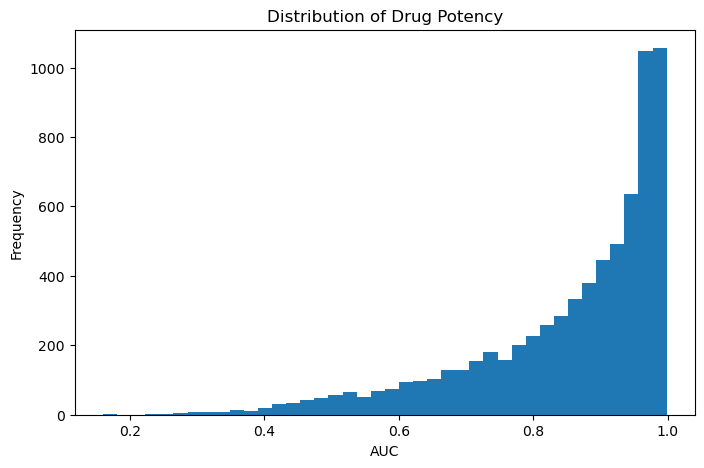

In [121]:
df=pd.read_csv("GDSC_DATASET.csv")
import pandas as pd
import numpy as np
pd.set_option('display.max_rows',None)
pd.set_option("display.max_columns",None)
from scipy.stats import pearsonr,skew
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
x_raw=df[["DRUG_NAME","GDSC Tissue descriptor 1","GDSC Tissue descriptor 2","TARGET","TARGET_PATHWAY","Microsatellite instability Status (MSI)","Growth Properties"]]
y=df["LN_IC50"]
x=pd.get_dummies(x_raw,drop_first=True)
model=LinearRegression()

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=40)
model.fit(x_train,y_train)
train_score=model.score(x_train,y_train)
test_score=model.score(x_test,y_test)
#print(model.coef_[0])
#print(train_score)

print(f"Training data set performance score is :{train_score}")
print(f"Testing data set performance score is :{test_score}")
y_pred = pd.Series(model.predict(x_test),index=x_test.index)
a=pd.DataFrame()
a["Predicted Drug Potency"]=y_pred
a["Actual Drug Potency"]=y_test
a["Tissue"] = df.loc[x_test.index,"GDSC Tissue descriptor 1"]
a["Sub_tissue"] = df.loc[x_test.index,"GDSC Tissue descriptor 2"]

#print(d)

print(
    a.groupby("Tissue")["Predicted Drug Potency"]
      .mean()
      .sort_values(ascending=False)
)
plt.figure(figsize=(8,5))
plt.hist(df["AUC"], bins=40)
plt.title("Distribution of Drug Potency")
plt.xlabel("AUC")
plt.ylabel("Frequency")
plt.show()
#print(f"Drug potency impact {y_pred}")


In [ ]:
# Response  prediction by considering AUC values against cancer cell properties and target mechanism

Tissue
breast               0.892206
kidney               0.890146
skin                 0.889121
urogenital_system    0.886215
nervous_system       0.884019
lung_NSCLC           0.882091
digestive_system     0.879717
pancreas             0.863550
aero_dig_tract       0.863368
large_intestine      0.858598
lung                 0.857133
thyroid              0.853798
lung_SCLC            0.852209
myeloma              0.824691
neuroblastoma        0.820533
lymphoma             0.786203
leukemia             0.733844
Name: Predicted_AUC, dtype: float64


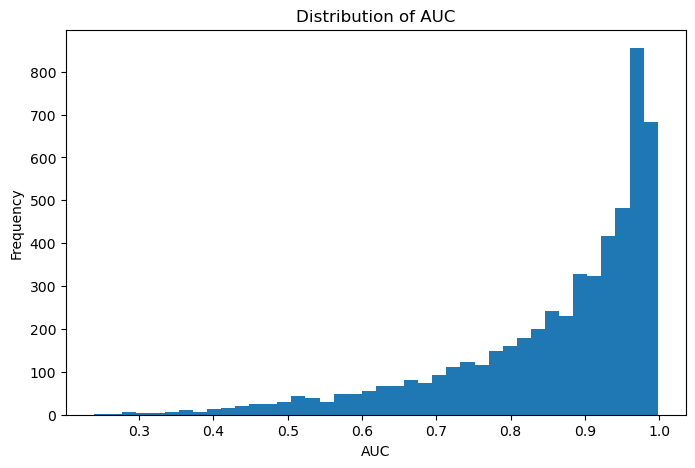

In [115]:
from sklearn.linear_model import LinearRegression
df.dropna(inplace = True)
x_raw=df[["DRUG_NAME","GDSC Tissue descriptor 1","GDSC Tissue descriptor 2","TARGET","TARGET_PATHWAY","Microsatellite instability Status (MSI)","Growth Properties"]]
y=df["AUC"]
x=pd.get_dummies(x_raw,drop_first=True)
model=LinearRegression()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=45)
model.fit(x_train,y_train)
y_pred=pd.Series(model.predict(x_test),index=x_test.index)
#print(f"Predicted AUC {y_pred}")
model.fit(x_train,y_train)

y_pred = pd.Series(model.predict(x_test), index=x_test.index)

d = pd.DataFrame()

d["Predicted_AUC"] = y_pred
d["Actual_AUC"] = y_test

d["Tissue"] = df.loc[x_test.index,"GDSC Tissue descriptor 1"]
d["Sub_tissue"] = df.loc[x_test.index,"GDSC Tissue descriptor 2"]

#print(d)

print(
    d.groupby("Tissue")["Predicted_AUC"]
      .mean()
      .sort_values(ascending=False)
)
plt.figure(figsize=(8,5))
plt.hist(df["AUC"], bins=40)
plt.title("Distribution of AUC")
plt.xlabel("AUC")
plt.ylabel("Frequency")
plt.show()

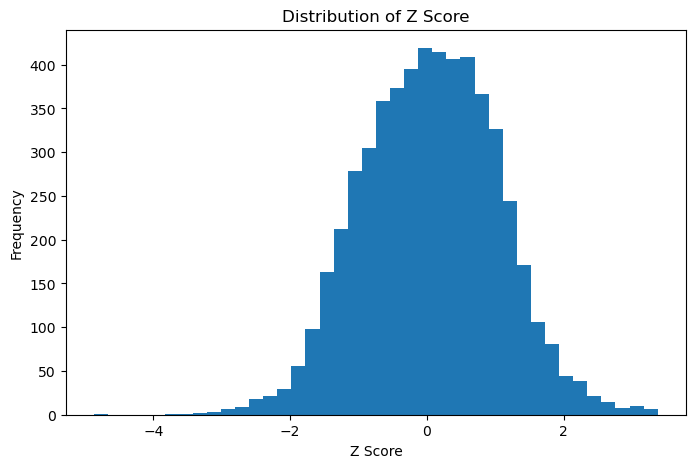

0
0
Sensitive
Z_Score is :0.5365465255842252


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [109]:
#Cancer drug comnination sensitivity
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
df.dropna(inplace=True)
x=df[["Z_SCORE"]]
a=x.median()
df["Sensitivity"]=np.where(x>a,1,0)
y=df["Sensitivity"]
model=LogisticRegression()
model.fit(x,y)

plt.figure(figsize=(8,5))
plt.hist(df["Z_SCORE"], bins=40)
plt.title("Distribution of Z Score")
plt.xlabel("Z Score")
plt.ylabel("Frequency")

plt.show()
test_input=np.array([[0.05]])

median_prediction=model.predict(test_input)[0]

print(median_prediction)
test_result_probability=model.predict_proba(test_input)[0]


print(median_prediction)
if median_prediction ==1:
    print("Resistant")
    print(f"Z_Score is :{test_result_probability[1]}")
else:
    print("Sensitive")
    print(f"Z_Score is :{test_result_probability[0]}")



In [80]:
# Response of variety of cell lines to Camptothecin 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
df=pd.read_csv("GDSC_DATASET.csv")
campto_df = df[df["DRUG_NAME"] == "Camptothecin"]

x_raw = campto_df[
    [
        "GDSC Tissue descriptor 1",
        "Cancer Type (matching TCGA label)",
        "Microsatellite instability Status (MSI)",
        "Growth Properties",
        "CNA",
        "Gene Expression",
        "Methylation",
        "TARGET",
        "TARGET_PATHWAY"
    ]
]
x=pd.get_dummies(x_raw,drop_first=True)
a=campto_df["Z_SCORE"].median()
y = np.where(campto_df["Z_SCORE"]>a,1,0)
model=LogisticRegression()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model.fit(x_train,y_train)
test_input=x_test.iloc[[0]]
y_pred=model.predict(x_test)
target_prediction=model.predict(test_input)[0]
target_probability=model.predict_proba(test_input)[0]
if target_prediction==1:
    print(f"Cell line is sensitive to Camptothecin with a response level of :{target_probability[1]*100:.3f}%")
#print(median_prediction)
if target_prediction<1:
    print("Cell line is in-sensitive to Camptothecin")
tn,fp,fn,tp=confusion_matrix(y_test,y_pred).ravel()

print(f"Training accuracy is:{model.score(x_train,y_train)*100:.3f}")
print(f"Testingg accuracy is:{model.score(x_test,y_test)*100:.3f}")
print(f"Sensitive cellines identified correctly :{tp}")
print(f"Uneffcitive cell lines identified correctly :{tn}")
print(f"Sensitive cell lines missed:{tn}")
print(f"Unsensitive cell lines marked as sensitive:{fp}")

Cell line is sensitive to Camptothecin with a response level of :64.705%
Training accuracy is:70.483
Testingg accuracy is:66.942
Sensitive cellines identified correctly :86
Uneffcitive cell lines identified correctly :76
Sensitive cell lines missed:76
Unsensitive cell lines marked as sensitive:35


In [81]:
#Melanoma - Drug response prediction , based on biological factors
from sklearn.linear_model import LogisticRegression

mela_df=df[df["GDSC Tissue descriptor 2"]=="melanoma"]
x_raw=mela_df[["CELL_LINE_NAME","DRUG_NAME","Microsatellite instability Status (MSI)","Screen Medium","Growth Properties"]]
x=pd.get_dummies(x_raw,drop_first=True)
a=mela_df["Z_SCORE"].median()
y=np.where(mela_df["Z_SCORE"]>a,1,0)
model=LogisticRegression()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model.fit(x_train,y_train)
test_input=x_test.iloc[[0]]
y_pred = model.predict(x_test)
test_pred=model.predict(test_input)[0]
test_pred_prob=model.predict_proba(test_input)[0]
if test_pred==1:
    print(f"For melanoma , the selected cell line of the mentioned bioloigcal factors is found to be sensitive with Z score of {test_pred_prob[1]}")
elif test_pred==0:
    print(f"For melanoma , the selected cell line of the mentioned bioloigcal factors is found to be resistive with Z score of {test_pred_prob[0]}")
tn,fp,fn,tp=confusion_matrix(y_test,y_pred).ravel()

print(f"Training accuracy is:{model.score(x_train,y_train)*100:.3f}")
print(f"Testing accuracy is:{model.score(x_test,y_test)*100:.3f}")
print(f"Sensitive cellines identified correctly :{tp}")
print(f"Uneffcitive cell lines identified correctly :{tn}")
print(f"Sensitive cell lines missed:{fn}")
print(f"Unsensitive cell lines marked as sensitive:{fp}")


For melanoma , the selected cell line of the mentioned bioloigcal factors is found to be resistive with Z score of 0.5672287562578927
Training accuracy is:78.148
Testing accuracy is:61.538
Sensitive cellines identified correctly :27
Uneffcitive cell lines identified correctly :29
Sensitive cell lines missed:21
Unsensitive cell lines marked as sensitive:14


In [82]:
#Analysing sensitivity of each drug to melanoma cancer type
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
df=pd.read_csv("GDSC_DATASET.csv")
mela_df=df[df["GDSC Tissue descriptor 2"]=="melanoma"]
x_raw=mela_df[["CELL_LINE_NAME","DRUG_NAME","Microsatellite instability Status (MSI)","Screen Medium","Growth Properties"]]
x=pd.get_dummies(x_raw,drop_first=True)
a=mela_df["Z_SCORE"].median()
y=np.where(mela_df["Z_SCORE"]>a,1,0)
model=LogisticRegression()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model.fit(x,y)
all_pred=model.predict(x)
#mela_df["Predictions"]=all_pred
#mela_df.groupby("GDSC Tissue descriptor 1")
#print(mela_df)
#all_pred=list(all_pred)
y_pred=model.predict(x_test)
mela_df=mela_df.copy()
mela_df["Predictions"]=all_pred
mela_df.groupby("DRUG_NAME")
tn,fp,fn,tp=confusion_matrix(y_test,y_pred).ravel()

print(f"Training accuracy is:{model.score(x_train,y_train)*100:.3f}")
print(f"Testingg accuracy is:{model.score(x_test,y_test)*100:.3f}")
print(f"Sensitive drugs identified correctly :{tp}")
print(f"Uneffcitive drugs identified correctly :{tn}")
print(f"Sensitive drugs missed:{tn}")
print(f"Unsensitive  drugs marked as sensitive:{fp}")

Training accuracy is:77.037
Testingg accuracy is:71.429
Sensitive drugs identified correctly :34
Uneffcitive drugs identified correctly :31
Sensitive drugs missed:31
Unsensitive  drugs marked as sensitive:12


              precision    recall  f1-score   support

           0       0.88      0.88      0.88       899
           1       0.87      0.87      0.87       839

    accuracy                           0.88      1738
   macro avg       0.88      0.88      0.88      1738
weighted avg       0.88      0.88      0.88      1738



[Text(0.7885416666666667, 0.9375, 'TARGET_PATHWAY_Mitosis <= 0.5\nentropy = 1.0\nsamples = 5211\nvalue = [2580, 2631]\nclass = Resistant'),
 Text(0.64375, 0.8125, 'TARGET_TOP1 <= 0.5\nentropy = 0.923\nsamples = 3934\nvalue = [1332, 2602]\nclass = Resistant'),
 Text(0.7161458333333334, 0.875, 'True  '),
 Text(0.45416666666666666, 0.6875, 'DRUG_NAME_Methotrexate <= 0.5\nentropy = 0.747\nsamples = 3223\nvalue = [686, 2537]\nclass = Resistant'),
 Text(0.2625, 0.5625, 'Growth Properties_Suspension <= 0.5\nentropy = 0.596\nsamples = 2568\nvalue = [371, 2197]\nclass = Resistant'),
 Text(0.13333333333333333, 0.4375, 'DRUG_NAME_Cytarabine <= 0.5\nentropy = 0.442\nsamples = 1951\nvalue = [179, 1772]\nclass = Resistant'),
 Text(0.06666666666666667, 0.3125, 'TARGET_BCL2, BCL-XL, BCL-W <= 0.5\nentropy = 0.315\nsamples = 1528\nvalue = [87, 1441]\nclass = Resistant'),
 Text(0.03333333333333333, 0.1875, 'CELL_LINE_NAME_EC-GI-10 <= 0.5\nentropy = 0.184\nsamples = 1112\nvalue = [31, 1081]\nclass = Resis

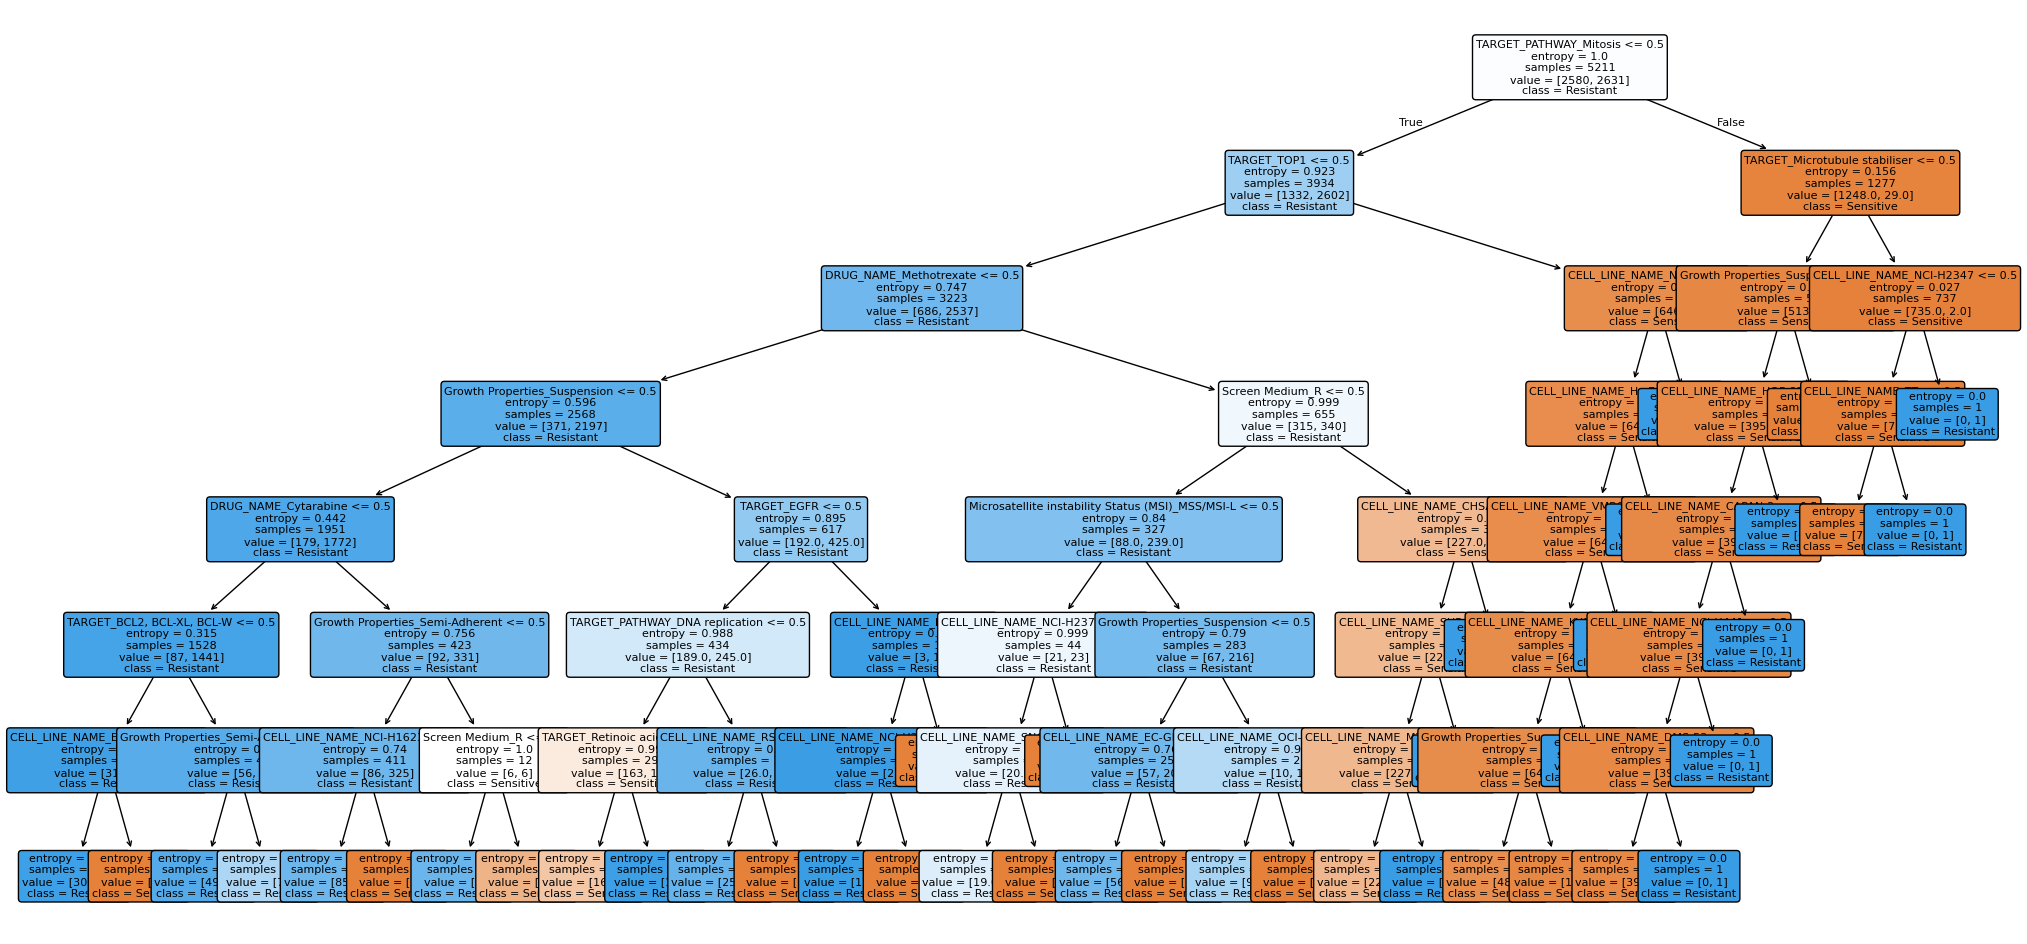

In [114]:
#Decision tree classifier of sensitivity of tumor towards a drug
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
df=pd.read_csv("GDSC_DATASET.csv")
x_raw=df[["CELL_LINE_NAME","DRUG_NAME","Microsatellite instability Status (MSI)","Screen Medium","Growth Properties","TARGET","TARGET_PATHWAY"]]
x=pd.get_dummies(x_raw,drop_first=True)
a=df["LN_IC50"].median()
y=np.where(df["LN_IC50"]>a,1,0)
model=DecisionTreeClassifier(criterion='entropy',max_depth=7,random_state=42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
tree_rules = tree.export_text(model, feature_names=list(x_test.columns))
print(classification_report(y_pred,y_test))


import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(25,12))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Sensitive","Resistant"],
    filled=True,
    rounded=True,
    fontsize=8
)